# **Gasto de Bolsillo en Salud y Medicamentos en Perú 2019-2025**
+ **Autor:** [Facundo Cabral](https://facundocabralvaldivia.github.io/portfolio/index.html)
+ **Fecha:** Mayo 2026

Análisis del gasto de bolsillo en salud y medicamentos en Perú en el periodo 2019-2025 con data de la [Encuesta Nacional de Hogares (ENAHO)](https://proyectos.inei.gob.pe/microdatos/) realizada por el Instituto Nacional de Estadística e Informática (INEI) en el mismo periodo de años. Se emplea el módulo de salud (400) para obtener los datos de gasto y la sumaria para obtener la variable de pobreza y permitir hacer un análisis socioeconómico.  

En el módulo 400 se diferencia 16 categorías de gasto en salud las cuales han sido agrupadas de la siguiente manera para el presente análisis:

| **Categoría Agrupada** | **Categorías Originales** |
|------------------------|---------------------------|
| Medicinas              | Medicinas (2)            |
| Consulta y Diagnóstico Ambulatorio | Consultas (1), Análisis (3), Rayos X (4), Otros exámenes (5) |
| Atención Dental y Ocular | Servicio dental (6), Oftalmólogo (7), Compra de Lentes (8) |
| Procedimientos Hospitalarios | Hospitalización (13), Intervención quirúrgica (14) |
| Salud Preventiva y Materno-infantil | Vacunas (9), Control de niños (10), Anticonceptivos (11), Control de embarazo (15), Atención de parto (16) |
| Otros Gastos | Otros Gastos (12) |

+ Se conficiona a que el gasto es pagado por algún miembro del hogar, con la variable `p4151_j == 1`, j=1,...,16.
+ Para capturar el gasto se utiliza la variable `i416_j`, j=1,...,16.
+ Para capturar el gasto generado por las personas con problemas de salud se filtra con la variable `p4025==0`
+ Para obtener el gasto a nivel poblacional se emplea el factor de expansión en cada base.

## **Librerías**

In [24]:
import pyreadstat
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

import warnings
warnings.filterwarnings('ignore')

## **Carga de Datos**

### Módulo de Salud

In [25]:
lista_enaho_400 = []

for anio in range(2019, 2026):
    ruta            = f"data/modulo_400/enaho01a-{anio}-400.dta"
    df_anio, meta   = pyreadstat.read_dta(ruta)
    cols            = df_anio.select_dtypes(include=["float"]).columns
    df_anio[cols]   = df_anio[cols].astype(np.float64)
    df_anio["anio"] = anio
    lista_enaho_400.append(df_anio.copy())

df = pd.concat(lista_enaho_400, ignore_index=True)

### Sumarias

In [26]:
lista_enaho_sumaria = []

for anio in range(2019, 2026):
    ruta            = f"data/sumaria/sumaria-{anio}.dta"
    df_anio, meta   = pyreadstat.read_dta(ruta)
    cols            = df_anio.select_dtypes(include=["float"]).columns
    df_anio[cols]   = df_anio[cols].astype(np.float64)
    df_anio["anio"] = anio
    lista_enaho_sumaria.append(df_anio.copy())

sumaria = pd.concat(lista_enaho_sumaria, ignore_index=True)

### Merge

In [27]:
cols_merge    = ["anio", "mes", "conglome", "vivienda", "hogar"]
cols_sumaria  = cols_merge + ["pobreza"]
sumaria_merge = sumaria[cols_sumaria].copy()

df = df.merge(sumaria_merge, on=cols_merge, how="left")

## **Variables**

### Variables de Gasto en Salud

In [28]:
# Creamos una variable por cada tipo de gasto en salud
var_tipos_gasto = {}

for i in range(1, 17):
    j = f"{i:02d}"
    var_tipos_gasto[f"gto{j}"] = np.where(
        df[f"p4151_{j}"] == 1,  # Pagado por algún miembro del hoga
        df[f"i416{j}"],         # Gasto imputado
        0
    )

df_var_tipos_gasto = pd.DataFrame(var_tipos_gasto, index=df.index)
df = pd.concat([df, df_var_tipos_gasto], axis=1)

In [29]:
# Generamos el gasto total por cada usuario
gto_cols          = [f"gto{i:02d}" for i in range(1, 17)]
df["gto_usuario"] = df[gto_cols].sum(axis=1)

### Factor de Expansión
Dada la pandemia, la realización de la ENAHO fue complicada, por lo que la INEI para el año 2020y 2021 varió los factores de expansión para conservar la mayor data posible.

In [30]:
df["factor_exp"] = df["factor07"]

# Factor de expansión para 2020
mask_2020 = (df["anio"] == 2020) & df["factor_p"].notna()
df.loc[mask_2020, "factor_exp"] = df.loc[mask_2020, "factor_p"]

# Factor de expansión para 2021
mask_2021 = df["anio"] == 2021
df.loc[mask_2021, "factor_exp"] = df.loc[mask_2021, "factor_p"]

### Condicionante

In [31]:
df["problema_salud"] = np.where(df["p4025"] == 0, 1, 0)
df_problema_s = df[df["problema_salud"] == 1]

## **Gasto de Bolsillo en Salud**

### Gasto a Nivel Nacional
Gasto desagregado por categoría a través de los años en millones de soles

In [32]:
gto_anio_des = []

for anio in range(2019, 2026):
    df_anio = df[df["anio"] == anio]
    fila = {"anio": anio}
    for col in gto_cols:
        gto_expandido = df_anio[col] * df_anio["factor_exp"]
        fila[col] = np.nansum(gto_expandido) / 1_000_000
    gto_anio_des.append(fila)

tb_gto_salud_des = pd.DataFrame(gto_anio_des).set_index("anio")
tb_gto_salud_des.round(1)

,gto01,gto02,gto03,gto04,gto05,gto06,gto07,gto08,gto09,gto10,gto11,gto12,gto13,gto14,gto15,gto16
anio,,,,,,,,,,,,,,,,
2019,715.5,4467.3,426.5,500.8,234.6,1816.6,140.8,722.7,34.6,7.5,94.9,1238.1,323.1,529.7,18.2,25.8
2020,746.3,4735.7,505.2,496.4,283.7,1795.6,136.6,672.0,30.9,10.3,79.0,2714.3,265.9,444.4,14.6,36.9
2021,802.4,4849.7,731.3,663.7,194.4,1681.6,124.3,618.9,21.3,9.4,81.7,4161.9,372.0,674.6,23.4,29.6
2022,789.3,5403.7,480.1,618.9,320.1,2192.4,176.5,838.7,8.8,6.9,80.7,3342.2,342.9,815.8,15.3,17.9
2023,928.1,5799.4,597.3,591.1,342.8,2401.7,188.9,912.3,5.9,9.0,91.4,2169.9,368.7,804.1,14.2,8.1
2024,783.6,5255.8,482.3,514.7,418.3,2639.2,186.8,961.4,18.5,3.2,83.1,1829.5,345.5,874.6,12.8,18.9
2025,834.8,5143.4,542.1,633.5,503.2,2251.8,186.8,927.5,15.4,5.0,70.5,1739.0,302.3,721.4,12.6,7.3


Gasto total a través de los años en millones de soles

In [33]:
gto_anio_total = tb_gto_salud_des[gto_cols].sum(axis=1)

tb_total_nacional = pd.DataFrame(index=tb_gto_salud_des.index)
tb_total_nacional["gto_salud_tot"] = gto_anio_total
tb_total_nacional.round(1)

,gto_salud_tot
anio,
2019,11296.7
2020,12968.0
2021,15040.4
2022,15450.3
2023,15232.8
2024,14428.1
2025,13896.7


### Gasto Nacional de Personas con Problema de Salud
Gasto desagregado por categoría a través de los años en millones de soles

In [34]:
gto_ps_anio_des = []

for anio in range(2019, 2026):
    df_anio = df_problema_s[df_problema_s["anio"] == anio]
    fila = {"anio": anio}
    for col in gto_cols:
        gto_ps_expandido = df_anio[col] * df_anio["factor_exp"]
        fila[col] = np.nansum(gto_ps_expandido) / 1_000_000
    gto_ps_anio_des.append(fila)

tb_gto_ps_salud_des = pd.DataFrame(gto_ps_anio_des).set_index("anio")
tb_gto_ps_salud_des.round(1)

,gto01,gto02,gto03,gto04,gto05,gto06,gto07,gto08,gto09,gto10,gto11,gto12,gto13,gto14,gto15,gto16
anio,,,,,,,,,,,,,,,,
2019,703.0,4123.7,414.4,476.8,195.1,1087.7,87.1,470.1,14.4,3.8,57.9,823.0,205.5,362.8,10.6,16.5
2020,696.9,4166.8,461.6,446.0,245.1,1030.6,70.6,343.3,12.3,3.8,42.6,1525.2,133.9,225.6,8.0,10.8
2021,748.2,4222.2,653.7,588.2,170.3,852.5,66.9,308.3,6.1,2.6,43.4,2262.4,233.0,322.7,11.1,14.0
2022,758.0,4813.6,420.2,563.5,270.0,1076.8,90.6,456.2,3.8,4.2,42.9,1906.7,218.5,502.3,8.8,8.2
2023,855.2,5134.5,511.9,537.2,287.4,1278.2,115.1,542.5,3.1,4.3,51.5,1398.3,244.1,404.0,6.9,2.8
2024,746.2,4741.2,449.6,473.0,319.2,1460.1,112.2,592.8,9.9,0.6,49.5,1202.1,223.6,615.1,6.5,7.2
2025,801.2,4719.9,519.2,600.6,437.1,1204.7,112.8,566.2,10.2,1.9,39.8,1158.0,235.7,521.8,7.8,3.3


Gasto desagregado por problema de salud a través de los años

In [35]:
gto_ps_anio_total = tb_gto_ps_salud_des[gto_cols].sum(axis=1)

tb_ps_total_nacional = pd.DataFrame(index=tb_gto_salud_des.index)
tb_ps_total_nacional["gto_ps_salud_tot"]     = gto_ps_anio_total
tb_ps_total_nacional["gto_psnt_salud_tot"]   = gto_anio_total - gto_ps_anio_total
tb_ps_total_nacional["gto_ps_salud_tot_pct"] = gto_ps_anio_total / gto_anio_total * 100
tb_ps_total_nacional.round(1)

,gto_ps_salud_tot,gto_psnt_salud_tot,gto_ps_salud_tot_pct
anio,,,
2019,9052.5,2244.2,80.1
2020,9423.1,3544.9,72.7
2021,10505.8,4534.6,69.9
2022,11144.2,4306.1,72.1
2023,11376.9,3855.9,74.7
2024,11009.2,3418.9,76.3
2025,10940.0,2956.7,78.7


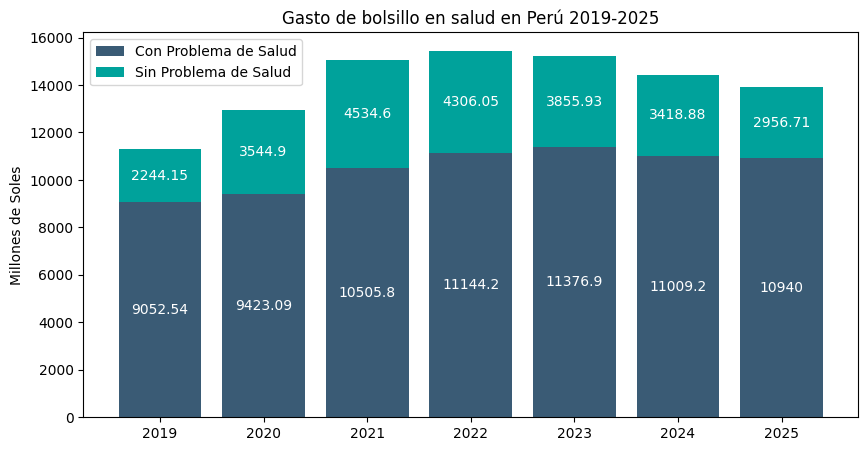

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

barra1 = ax.bar(
    range(2019,2026),
    tb_ps_total_nacional['gto_ps_salud_tot'],
    label='Con Problema de Salud',
    color='#3A5B75'
)
barra2 = ax.bar(
    range(2019,2026),
    tb_ps_total_nacional['gto_psnt_salud_tot'],
    bottom=tb_ps_total_nacional['gto_ps_salud_tot'],
    label='Sin Problema de Salud',
    color='#00A29B'
)
ax.bar_label(barra1, label_type='center', color='white')
ax.bar_label(barra2, label_type='center', color='white')
ax.set_ylabel('Millones de Soles')
ax.set_title('Gasto de bolsillo en salud en Perú 2019-2025')
ax.legend()

# Mostrar gráfico
plt.show()

Gasto de personas con problemas de salud agrupados por categoría a través de los años

In [37]:
gto_agrupados = {
    'Medicinas': ['gto02'],
    'Consulta y Diagnóstico Ambulatorio': ['gto01', 'gto03', 'gto04', 'gto05'],
    'Atención Dental y Ocular': ['gto06', 'gto07', 'gto08'],
    'Procedimientos Hospitalarios': ['gto13', 'gto14'],
    'Salud Preventiva y Materno-infantil': ['gto09', 'gto10', 'gto11', 'gto15', 'gto16'],
    'Otros Gastos': ['gto12']
}

tb_gto_ps_salud_agr = pd.DataFrame(index=tb_gto_ps_salud_des.index)
for cat, col in gto_agrupados.items():
    tb_gto_ps_salud_agr[cat] = tb_gto_ps_salud_des[col].sum(axis=1)

tb_gto_ps_salud_agr.round(1)

,Medicinas,Consulta y Diagnóstico Ambulatorio,Atención Dental y Ocular,Procedimientos Hospitalarios,Salud Preventiva y Materno-infantil,Otros Gastos
anio,,,,,,
2019,4123.7,1789.3,1644.9,568.3,103.2,823.0
2020,4166.8,1849.6,1444.5,359.5,77.5,1525.2
2021,4222.2,2160.4,1227.7,555.7,77.3,2262.4
2022,4813.6,2011.6,1623.6,720.8,67.8,1906.7
2023,5134.5,2191.6,1935.7,648.1,68.6,1398.3
2024,4741.2,1988.1,2165.2,838.7,73.8,1202.1
2025,4719.9,2358.1,1883.6,757.5,63.0,1158.0


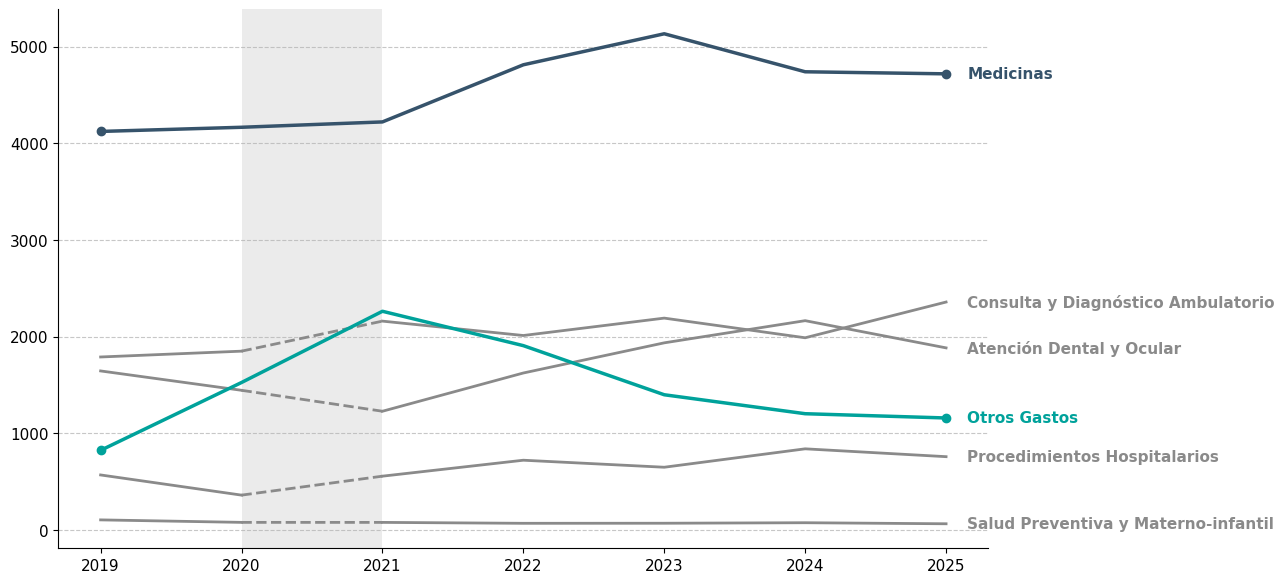

In [38]:
colores = {
    'Medicinas'    : '#36536b',
    'Otros Gastos' : '#00A29B',
    'Gris'         : '#8A8A8A'
}

fig, ax = plt.subplots(figsize=(12, 7))

anios = tb_gto_ps_salud_agr.index

ax.axvspan(2020, 2021, facecolor='#e6e6e6', alpha=0.8, zorder=0)

for categoria in tb_gto_ps_salud_agr.columns:
    valores = tb_gto_ps_salud_agr[categoria]
    
    if categoria in ['Medicinas', 'Otros Gastos']:
        color_linea = colores[categoria]
        ax.plot(anios, valores, color=color_linea, linewidth=2.5, zorder=5)
        ax.plot([anios[0], anios[-1]], [valores.iloc[0], valores.iloc[-1]], 
                color=color_linea, marker='o', markersize=6, linestyle='', zorder=6)
        
    else:
        color_linea = colores['Gris']
        ax.plot(anios[:2], valores.iloc[:2], color=color_linea, linewidth=2, zorder=3)
        ax.plot(anios[1:3], valores.iloc[1:3], color=color_linea, linewidth=2, linestyle='--', zorder=3)
        ax.plot(anios[2:], valores.iloc[2:], color=color_linea, linewidth=2, zorder=3)

    ax.text(
        anios[-1] + 0.15,
        valores.iloc[-1],
        categoria,
        color=color_linea,
        va='center',
        fontweight='bold',
        fontsize=11
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

### Gasto de Bolsillo Per Cápita en Medicamentos de Personas con Problemas de Salud por Departamento

In [39]:
df["dpto"] = df["ubigeo"].astype(str).str.zfill(6).str[:2]

nombres_dpto = {
    "01": "AMAZONAS", "02": "ANCASH", "03": "APURIMAC", "04": "AREQUIPA", "05": "AYACUCHO",
    "06": "CAJAMARCA", "07": "CALLAO", "08": "CUSCO", "09": "HUANCAVELICA", "10": "HUANUCO",
    "11": "ICA", "12": "JUNIN", "13": "LA LIBERTAD", "14": "LAMBAYEQUE", "15": "LIMA",
    "16": "LORETO", "17": "MADRE DE DIOS", "18": "MOQUEGUA", "19": "PASCO", "20": "PIURA",
    "21": "PUNO", "22": "SAN MARTIN", "23": "TACNA", "24": "TUMBES", "25": "UCAYALI",
}

dptos = sorted(df["dpto"].unique())
columnas_dpto = [nombres_dpto[d] for d in dptos]

In [48]:
tb_gto_ps_medi_dpto = pd.DataFrame(index=anios, columns=columnas_dpto, dtype=float)

for anio in range(2019, 2026):
    df_anio = df[df["anio"] == anio]

    for dpto in dptos:
        df_dep = df_anio[df_anio["dpto"] == dpto]
        nombre = nombres_dpto[dpto]

        gasto_medicinas = np.nansum(df_dep["gto02"] * df_dep["factor_exp"])
        poblacion = np.nansum(df_dep["factor07"])
        tb_gto_ps_medi_dpto.loc[anio, nombre] = gasto_medicinas / poblacion

tb_gto_ps_medi_dpto

,AMAZONAS,ANCASH,APURIMAC,AREQUIPA,AYACUCHO,CAJAMARCA,CALLAO,CUSCO,HUANCAVELICA,HUANUCO,...,LORETO,MADRE DE DIOS,MOQUEGUA,PASCO,PIURA,PUNO,SAN MARTIN,TACNA,TUMBES,UCAYALI
2019,92.586154,144.639447,57.761143,122.116499,89.677390,118.103173,129.629844,75.807821,69.572472,83.105085,...,56.875330,138.379094,75.755526,54.239354,132.350303,71.246191,128.507996,120.215358,115.470422,81.214453
2020,171.693642,139.582595,62.222670,126.188893,83.081584,134.728295,121.444036,87.912853,69.307738,107.674592,...,63.728084,104.718528,109.335268,71.108784,151.031895,68.723396,135.264413,122.643034,98.894598,98.756930
2021,149.522153,139.702118,60.438767,124.258875,84.583425,113.624866,142.391368,82.136134,51.544992,83.535038,...,63.355436,166.373464,68.275255,69.604769,147.358519,64.204325,168.387195,101.025959,93.486480,93.221488
2022,163.142606,173.658882,64.378742,154.180524,85.746510,158.090752,160.186341,78.497036,68.509019,74.514212,...,66.111774,149.110022,125.862253,93.636593,127.136433,89.757993,159.757307,140.615856,101.718765,123.332443
2023,176.122786,189.875956,88.500565,171.114896,97.034220,159.747114,172.419722,88.898098,68.500749,101.416753,...,61.512647,155.867917,93.210469,100.860643,160.659443,88.522461,153.533752,108.584887,143.735569,115.902303
2024,153.339209,156.880518,61.439897,139.698975,87.582549,136.249490,148.953430,102.056470,60.088495,86.384646,...,58.302797,127.324144,79.830886,89.063203,149.384688,109.564879,123.901604,114.153510,114.125262,128.901585
2025,179.669034,178.374008,72.455986,127.412900,91.462279,152.213286,139.067986,113.101425,38.606698,100.722740,...,58.422722,164.279336,86.835153,93.801659,140.332954,121.542851,138.376023,113.170622,79.478510,135.297081


In [41]:
tb_gto_ps_medi_dpto_25 = tb_gto_ps_medi_dpto.loc[2025,:]
gdf = gpd.read_file("data/shapefile/DEPARTAMENTOS_inei_geogpsperu_suyopomalia.shp")
gdf = gdf[['NOMBDEP','geometry']].copy()
gdf["gto_ps_medi"] = gdf["NOMBDEP"].map(tb_gto_ps_medi_dpto_25)
gdf

,NOMBDEP,geometry,gto_ps_medi
0,AMAZONAS,"POLYGON ((-77.81211 -2.98962, -77.81332 -2.990...",179.669034
1,ANCASH,"POLYGON ((-77.64692 -8.05086, -77.64669 -8.052...",178.374008
2,APURIMAC,"POLYGON ((-73.74632 -13.17456, -73.7457 -13.17...",72.455986
3,AREQUIPA,"POLYGON ((-71.98109 -14.64062, -71.98093 -14.6...",127.412900
4,AYACUCHO,"POLYGON ((-74.34843 -12.17503, -74.35 -12.1758...",91.462279
5,CAJAMARCA,"POLYGON ((-78.70034 -4.62769, -78.69817 -4.629...",152.213286
6,CALLAO,"POLYGON ((-77.13521 -11.81782, -77.13516 -11.8...",139.067986
7,CUSCO,"POLYGON ((-72.9728 -11.25189, -72.97134 -11.25...",113.101425
8,HUANCAVELICA,"POLYGON ((-74.57118 -11.9871, -74.57095 -11.98...",38.606698
9,HUANUCO,"POLYGON ((-76.00486 -8.30517, -76.00301 -8.305...",100.722740


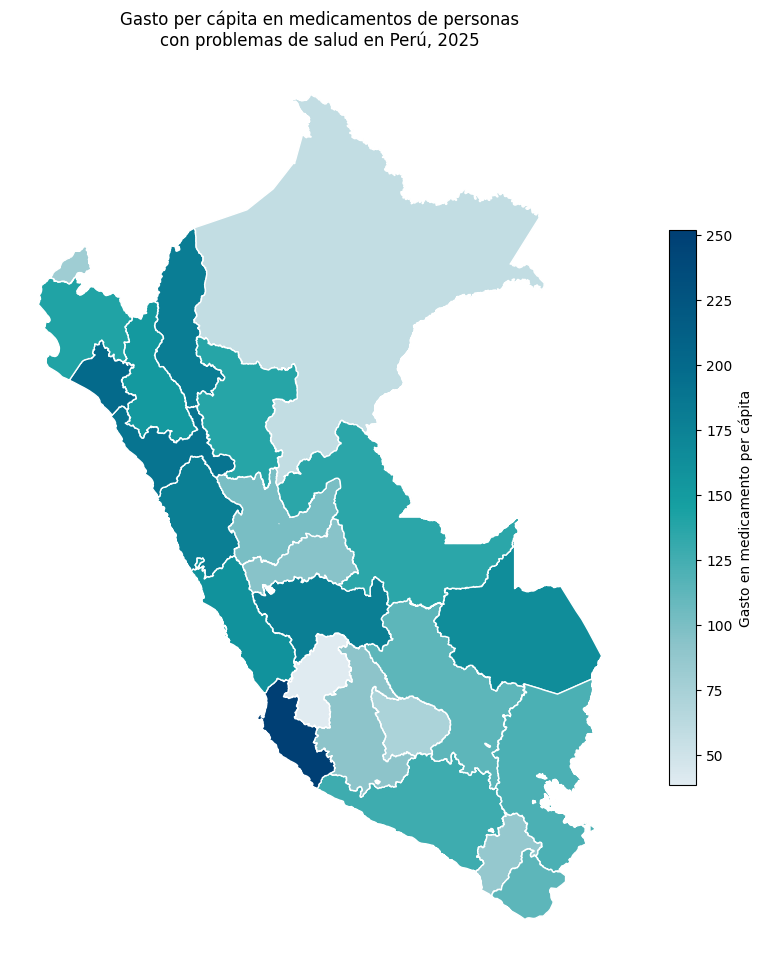

In [42]:
colores = ['#E0EBF1', '#8CC4CA', '#16A0A2', '#046B8C', '#003F74']

mi_cmap = LinearSegmentedColormap.from_list("mi_paleta_salud", colores)
fig, ax = plt.subplots(figsize=(10, 12))

gdf.plot(
    column="gto_ps_medi",
    cmap=mi_cmap,
    linewidth=1,
    edgecolor="#FFFFFF",
    legend=True,
    legend_kwds={
        "label": "Gasto en medicamento per cápita",
        "orientation": "vertical",
        "shrink": 0.6,
    },
    ax=ax,
)

ax.set_title("Gasto per cápita en medicamentos de personas\ncon problemas de salud en Perú, 2025")
ax.set_axis_off()
plt.show()

## Gasto de bolsillo en medicamentos por lugar de compra, pobreza y grupo etario

### Por lugar de compra

El lugar de compra de los medicamentos se obtiene de la variable `p417_02` la cual ha sido agrupada de la siguiente manera:

| **Categoría Agrupada** | **Categorías Originales** |
|------------------------|---------------------------|
| Farmacia o Botica | Farmacia o Botica (5) |
| Clinica o Consultorio | Clínica particular (6), Consultorio particular (7) |
| Establecimiento MINSA/EsSalud | Establecimientos MINSA (1), Establecimientos ESSALUD (2) |
| Otro | Hospital de las FF.AA. y Policía Nacional(3), Botiquín Comunal (4), CLAS (8), ONG (9), Óptica (10), Bodega (11), Casa de Huesero, Curandero (12), Ambulamte (13), Otro (14) |


In [51]:
df_med = df[df["gto02"] > 0].copy()

In [63]:
map_lugar_compra = {
    1 : "Establecimientos MINSA",
    2 : "Establecimientos EsSalud",
    3 : "Hospital FFAA/PNP",
    4 : "Botiquín comunal",
    5 : "Farmacia o botica",
    6 : "Clínica particular",
    7 : "Consultorio particular",
    8 : "CLAS",
    9 : "ONG",
    10: "Óptica",
    11: "Bodega",
    12: "Casa de huesero/curandero",
    13: "Ambulante",
    14: "Otro",
}
df_med["lugar_compra"] = df_med["p417_02"].map(map_lugar_compra)

In [64]:
categorias_lugar = [map_lugar_compra[i] for i in range(1, 15)]

tb_gto_med_lugar = pd.DataFrame(index=categorias_lugar, columns=range(2019, 2026), dtype=float)
for anio in range(2019, 2026):
    df_anio = df_med[df_med["anio"] == anio]
    for codigo in range(1, 15):
        df_cat   = df_anio[df_anio["p417_02"] == codigo]
        etiqueta = map_lugar_compra[codigo]
        tb_gto_med_lugar.loc[etiqueta, anio] = (
            np.nansum(df_cat["gto02"] * df_cat["factor_exp"]) / 1_000_000
        )

tb_gto_med_lugar.round(1)

,2019,2020,2021,2022,2023,2024,2025
Establecimientos MINSA,81.9,75.0,47.0,45.0,34.4,38.2,42.5
Establecimientos EsSalud,13.4,29.1,7.7,27.1,35.4,15.3,28.6
Hospital FFAA/PNP,4.7,7.2,0.3,1.7,1.8,4.5,10.8
Botiquín comunal,6.6,6.7,9.9,17.1,12.6,5.7,12.6
Farmacia o botica,3926.5,4001.4,4425.7,4901.1,5255.1,4769.5,4505.9
Clínica particular,248.1,234.2,163.0,178.8,234.3,203.5,261.6
Consultorio particular,58.7,74.0,49.3,72.1,56.0,73.0,110.3
CLAS,0.4,0.8,0.1,0.1,0.0,2.5,0.0
ONG,0.0,0.0,0.1,0.0,8.1,0.0,0.0
Óptica,0.1,0.1,0.4,0.0,0.3,0.1,4.7


In [111]:
mapeo_categorias = {
    'Farmacia o botica'         : 'Farmacia o Botica',
    'Clínica particular'        : 'Clinica o Consultorio',
    'Consultorio particular'    : 'Clinica o Consultorio',
    'Hospital FFAA/PNP'         : 'Otro',
    'Establecimientos MINSA'    : 'Establecimiento MINSA/EsSalud',
    'Establecimientos EsSalud'  : 'Establecimiento MINSA/EsSalud',
    'Botiquín comunal'          : 'Otro',
    'CLAS'                      : 'Otro',
    'ONG'                       : 'Otro',
    'Óptica'                    : 'Otro',
    'Bodega'                    : 'Otro',
    'Casa de huesero/curandero' : 'Otro',
    'Ambulante'                 : 'Otro',
    'Otro'                      : 'Otro'
}

tb_gto_med_lugar_agr = tb_gto_med_lugar.groupby(mapeo_categorias).sum()
tb_gto_med_lugar_agr.round(1)

,2019,2020,2021,2022,2023,2024,2025
Clinica o Consultorio,306.8,308.2,212.3,250.9,290.3,276.5,371.9
Establecimiento MINSA/EsSalud,95.3,104.1,54.7,72.0,69.7,53.5,71.1
Farmacia o Botica,3926.5,4001.4,4425.7,4901.1,5255.1,4769.5,4505.9
Otro,138.7,186.8,156.8,179.7,183.5,155.1,192.7


In [109]:
tb_gto_med_lugar_agr.T

,Clinica o Consultorio,Establecimiento MINSA/EsSalud,Farmacia o Botica,Hospital FFAA/PNP,Otro
2019,306.774188,95.290011,3926.502026,4.679088,134.007488
2020,308.184724,104.134059,4001.371219,7.212434,179.613303
2021,212.267703,54.686455,4425.696869,0.275699,156.545137
2022,250.891630,72.033994,4901.112601,1.706562,177.962318
2023,290.268295,69.733283,5255.143980,1.806179,181.700127
2024,276.465012,53.548944,4769.507019,4.475654,150.656551
2025,371.866844,71.102125,4505.865451,10.840134,181.844576


### Por nivel socioeconómico (pobreza)

In [66]:
map_nivel_pobreza = {
    1 : "Pobre extremo",
    2 : "Pobre no extremo",
    3 : "No pobre"
}
df_med["nivel_pobreza"] = df_med["pobreza"].map(map_nivel_pobreza)

In [105]:
categorias_pobreza = [map_nivel_pobreza[i] for i in range(1, 4)]

tb_med_pobreza_gasto = pd.DataFrame(index=categorias_pobreza, columns=range(2019, 2026), dtype=float)
for anio in range(2019, 2026):
    df_anio = df_med[df_med["anio"] == anio]
    
    for categoria in categorias_pobreza:
        df_cat = df_anio[df_anio["nivel_pobreza"] == categoria]
        
        tb_med_pobreza_gasto.loc[categoria, anio] = (
            np.nansum(df_cat["gto02"] * df_cat["factor_exp"]) / 1_000_000
        )

tb_med_pobreza_gasto.round(1)

,2019,2020,2021,2022,2023,2024,2025
Pobre extremo,15.0,13.7,16.1,41.5,65.1,47.4,32.7
Pobre no extremo,213.4,259.8,314.7,521.6,568.2,475.7,347.8
No pobre,4238.8,4462.2,4518.9,4840.6,5166.1,4732.8,4762.9


### Por grupo etario

In [106]:
edad = df_med["p208a"]
df_med["grupo_etario"] = np.select(
    [edad <= 11, edad <= 17, edad <= 29, edad <= 59, edad >= 60],
    ["Niño (0-11)", "Adolescente (12-17)", "Joven (18-29)", "Adulto (30-59)", "Adulto mayor (60+)"],
    default=None,
)

In [108]:
categorias_etario = ["Niño (0-11)","Adolescente (12-17)","Joven (18-29)","Adulto (30-59)","Adulto mayor (60+)"]

tb_med_etario_gasto = pd.DataFrame(index=categorias_etario, columns=range(2019, 2026), dtype=float)
for anio in range(2019, 2026):
    df_anio = df_med[df_med["anio"] == anio]
    
    for categoria in categorias_etario:
        df_cat = df_anio[df_anio["grupo_etario"] == categoria]
        
        tb_med_etario_gasto.loc[categoria, anio] = (
            np.nansum(df_cat["gto02"] * df_cat["factor_exp"]) / 1_000_000
        )

tb_med_etario_gasto.round(1)

,2019,2020,2021,2022,2023,2024,2025
Niño (0-11),581.5,442.1,443.5,744.2,839.1,661.9,585.9
Adolescente (12-17),169.2,150.9,189.0,269.1,302.4,293.5,245.2
Joven (18-29),487.3,518.3,545.4,546.0,627.4,604.8,574.6
Adulto (30-59),1743.6,2074.6,2152.7,2278.0,2307.9,2140.2,1997.1
Adulto mayor (60+),1485.8,1549.7,1519.1,1566.4,1722.5,1555.4,1740.6
